In [1]:
from pathlib import Path
import re
import pandas as pd
from IPython.display import display

RESULT_DIR = Path('/home/syx/workspace/HyperBat/results/diffusion_results')

FILE_PATTERN = re.compile(
    r'^(?P<kind>end2end|test)_'
    r'local(?P<local_num_cycles>\d+)_'
    r'global(?P<global_num_cycles>\d+)_'
    r'steps(?P<diffusion_steps>\d+)_'
    r'dim(?P<denoiser_hidden_dim>\d+)_'
    r'wsize(?P<window_size>\d+)_'
    r'stride(?P<stride>\d+)\.csv$'
)


def _resolve_result_dir(result_dir=RESULT_DIR):
    result_dir = Path(result_dir)
    if result_dir.exists():
        return result_dir
    alt_dir = Path.cwd() / 'results' / 'diffusion_results'
    if alt_dir.exists():
        return alt_dir
    raise FileNotFoundError(f'Cannot find diffusion results directory: {result_dir}')


def _parse_filename(path):
    match = FILE_PATTERN.match(path.name)
    if not match:
        return None
    info = match.groupdict()
    info['path'] = path
    for key in ['local_num_cycles', 'global_num_cycles', 'diffusion_steps', 'denoiser_hidden_dim', 'window_size', 'stride']:
        info[key] = int(info[key])
    return info


def show_csv_results(
    result_dir=RESULT_DIR,
    filters=None,
    sort_by=None,
):
    """显示每个CSV文件中每个dataset的平均指标

    核心逻辑：
    1. 根据 filters 选择 CSV 文件（只有完全匹配的才参与统计）
    2. 对每个 CSV 文件，按 dataset 分组，计算该 dataset 内的平均指标
    3. 每行 = 一个 CSV 文件的一个 dataset 的数据
    4. 对参数列检查：如果全部相同，则隐藏该列
    5. 每个 dataset 单独一个表，按 mape 标记最优和次优行

    Parameters
    ----------
    result_dir : str or Path
        Folder containing result csv files.
    filters : dict or None
        Filename parameter filters, e.g. {'diffusion_steps': 1}.
        只有匹配所有 filter 条件的 CSV 文件才会被选中。
        未指定的参数可以有多个值。
    sort_by : list or None
        Sort keys for the final table. 默认按所有参数 + dataset 排序。
    """
    result_dir = _resolve_result_dir(result_dir)
    filters = filters or {}

    csv_files = []
    meta_rows = []
    for path in sorted(result_dir.glob('*.csv')):
        meta = _parse_filename(path)
        if meta is None or meta['kind'] != 'end2end':
            continue
        if any(meta.get(k) != v for k, v in filters.items()):
            continue
        csv_files.append(path)
        meta_rows.append({k: v for k, v in meta.items() if k != 'path'})

    if not csv_files:
        raise FileNotFoundError(f'No matching end2end csv files found in {result_dir} with filters={filters}')

    # 对每个 CSV 文件单独处理，每行 = 一个 CSV 的一个 dataset
    metric_cols = ['mse', 'mae', 'rmse', 'mape']
    param_cols = ['local_num_cycles', 'global_num_cycles', 'diffusion_steps', 'denoiser_hidden_dim', 'window_size', 'stride']

    frames = []
    for path, meta in zip(csv_files, meta_rows):
        df = pd.read_csv(path)

        # 对该 CSV 按 dataset 分组求平均
        grouped = df.groupby('dataset', as_index=False)[metric_cols].mean()

        # 为该 CSV 的结果添加参数列
        for key, value in meta.items():
            grouped[key] = value

        frames.append(grouped)

    all_data = pd.concat(frames, ignore_index=True)

    # 排序
    if sort_by is None:
        sort_by = param_cols + ['dataset']

    summary = all_data.sort_values(sort_by, ascending=True).reset_index(drop=True)

    # 检查哪些列全部一样
    hidden_cols = []
    hidden_values = {}

    for col in param_cols:
        if summary[col].nunique() == 1:
            hidden_cols.append(col)
            hidden_values[col] = summary[col].iloc[0]

    # 显示隐藏信息
    if hidden_cols:
        print("\n已隐藏全部相同的列：")
        for col in hidden_cols:
            print(f"  {col} = {hidden_values[col]}")
        print()

    print("根据MAPE指标高亮，最优行为绿色，次优行为红色。")

    # 每个dataset单独一个表
    for dataset in summary['dataset'].unique():
        dataset_mask = summary['dataset'] == dataset
        dataset_data = summary[dataset_mask].copy().reset_index(drop=True)

        # 重新排列列
        display_cols = ['dataset']
        for col in param_cols:
            if col not in hidden_cols:
                display_cols.append(col)
        display_cols.extend(metric_cols)

        display_df = dataset_data[display_cols].copy()

        # 对数值列进行格式化
        for col in metric_cols:
            display_df[col] = display_df[col].apply(lambda x: f'{x:.6f}')

        # 基于 mape 排名整行高亮：最优正绿色，次优正红色，字体黑色
        best_two = dataset_data['mape'].nsmallest(min(2, len(dataset_data))).index.tolist()
        best_idx = best_two[0] if len(best_two) >= 1 else None
        second_idx = best_two[1] if len(best_two) >= 2 else None

        def style_row_by_mape(row):
            if best_idx is not None and row.name == best_idx:
                return ['background-color: #00FF00; color: #000000'] * len(row)
            if second_idx is not None and row.name == second_idx:
                return ['background-color: #FF0000; color: #000000'] * len(row)
            return [''] * len(row)

        styled = display_df.style.apply(style_row_by_mape, axis=1)

        # 输出该dataset的表格
        display(styled)

    return summary


In [2]:
# 显示每个CSV文件中每个dataset的平均指标
# 特性：每个dataset单独一个表，按 mape 排名高亮（最优绿色，次优红色）

# 不指定 filter：所有 CSV 参与统计（150 行 = 25个CSV × 6个dataset）
# diffusion_steps 列会显示（因为有多个不同值）
result = show_csv_results()

# # 指定 filter：只有匹配条件的 CSV 参与统计
# # diffusion_steps 列会被隐藏（因为值恒定为 1）
# result = show_csv_results(filters={'diffusion_steps': 1})

# # 可以指定多个 filter
# result = show_csv_results(filters={'diffusion_steps': 1, 'local_num_cycles': 5})



已隐藏全部相同的列：
  denoiser_hidden_dim = 512
  window_size = 200
  stride = 50

根据MAPE指标高亮，最优行为绿色，次优行为红色。


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_CALCE,5,20,1,0.003692,0.051115,0.053302,0.057863
1,test_CALCE,5,20,3,0.005845,0.064675,0.067050,0.074316
2,test_CALCE,5,20,5,0.006587,0.066090,0.068708,0.076740
3,test_CALCE,5,20,10,0.006471,0.064714,0.067329,0.076255
4,test_CALCE,5,20,15,0.006946,0.069711,0.072065,0.080215
5,test_CALCE,5,20,20,0.008238,0.072705,0.075339,0.085298
6,test_CALCE,5,20,30,0.008611,0.075485,0.077936,0.086970
7,test_CALCE,5,20,40,0.010008,0.080958,0.083566,0.095187
8,test_CALCE,5,20,50,0.008543,0.074740,0.077451,0.087508
9,test_CALCE,5,20,75,0.009524,0.079653,0.082573,0.093781


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_HNEI,5,20,1,0.002487,0.042857,0.047653,0.051194
1,test_HNEI,5,20,3,0.003599,0.048306,0.053147,0.057938
2,test_HNEI,5,20,5,0.003683,0.049621,0.054663,0.059572
3,test_HNEI,5,20,10,0.006617,0.062955,0.068260,0.076131
4,test_HNEI,5,20,15,0.005120,0.056520,0.061534,0.068076
5,test_HNEI,5,20,20,0.005987,0.061798,0.066845,0.074933
6,test_HNEI,5,20,30,0.005287,0.055176,0.060414,0.066744
7,test_HNEI,5,20,40,0.006959,0.064223,0.069491,0.078326
8,test_HNEI,5,20,50,0.005262,0.056068,0.061916,0.067682
9,test_HNEI,5,20,75,0.005681,0.059027,0.064962,0.071230


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_HUST,5,20,1,0.003336,0.051882,0.052752,0.056129
1,test_HUST,5,20,3,0.003485,0.051605,0.052467,0.056048
2,test_HUST,5,20,5,0.003821,0.052788,0.053660,0.057407
3,test_HUST,5,20,10,0.004384,0.055078,0.055908,0.060429
4,test_HUST,5,20,15,0.004682,0.058022,0.058848,0.063035
5,test_HUST,5,20,20,0.004913,0.058644,0.059456,0.064293
6,test_HUST,5,20,30,0.005970,0.064512,0.065318,0.070173
7,test_HUST,5,20,40,0.005380,0.060644,0.061452,0.066104
8,test_HUST,5,20,50,0.005703,0.062729,0.063509,0.068502
9,test_HUST,5,20,75,0.005708,0.062166,0.062978,0.067944


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_MATR,5,20,1,0.006251,0.075404,0.076982,0.077450
1,test_MATR,5,20,3,0.006813,0.073534,0.075633,0.075823
2,test_MATR,5,20,5,0.007395,0.074220,0.076185,0.076405
3,test_MATR,5,20,10,0.008528,0.079186,0.081364,0.081634
4,test_MATR,5,20,15,0.010392,0.085691,0.087687,0.088178
5,test_MATR,5,20,20,0.009761,0.084066,0.086216,0.086794
6,test_MATR,5,20,30,0.014113,0.102254,0.104112,0.105229
7,test_MATR,5,20,40,0.012765,0.094862,0.097121,0.097805
8,test_MATR,5,20,50,0.012747,0.096651,0.098735,0.099534
9,test_MATR,5,20,75,0.011266,0.089012,0.091280,0.091739


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_NAion,5,20,1,0.001699,0.034910,0.040376,0.036739
1,test_NAion,5,20,3,0.002213,0.035875,0.041974,0.038108
2,test_NAion,5,20,5,0.002515,0.037961,0.044671,0.040318
3,test_NAion,5,20,10,0.002215,0.035812,0.042750,0.038540
4,test_NAion,5,20,15,0.002326,0.036261,0.043535,0.039181
5,test_NAion,5,20,20,0.002889,0.039873,0.046725,0.042829
6,test_NAion,5,20,30,0.002827,0.040618,0.047729,0.043745
7,test_NAion,5,20,40,0.002515,0.036754,0.043355,0.039545
8,test_NAion,5,20,50,0.002456,0.037442,0.044248,0.040145
9,test_NAion,5,20,75,0.008829,0.063363,0.069128,0.066815


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_ZNion,5,20,1,0.005176,0.061258,0.064505,0.067803
1,test_ZNion,5,20,3,0.010286,0.082466,0.085657,0.091625
2,test_ZNion,5,20,5,0.022040,0.126410,0.129102,0.139751
3,test_ZNion,5,20,10,0.034375,0.164414,0.166687,0.182496
4,test_ZNion,5,20,15,0.033706,0.165248,0.167449,0.183149
5,test_ZNion,5,20,20,0.028471,0.146906,0.149412,0.163207
6,test_ZNion,5,20,30,0.025504,0.136583,0.139253,0.151342
7,test_ZNion,5,20,40,0.023281,0.128742,0.131482,0.143246
8,test_ZNion,5,20,50,0.019739,0.120631,0.123322,0.134837
9,test_ZNion,5,20,75,0.016670,0.107893,0.110864,0.121060


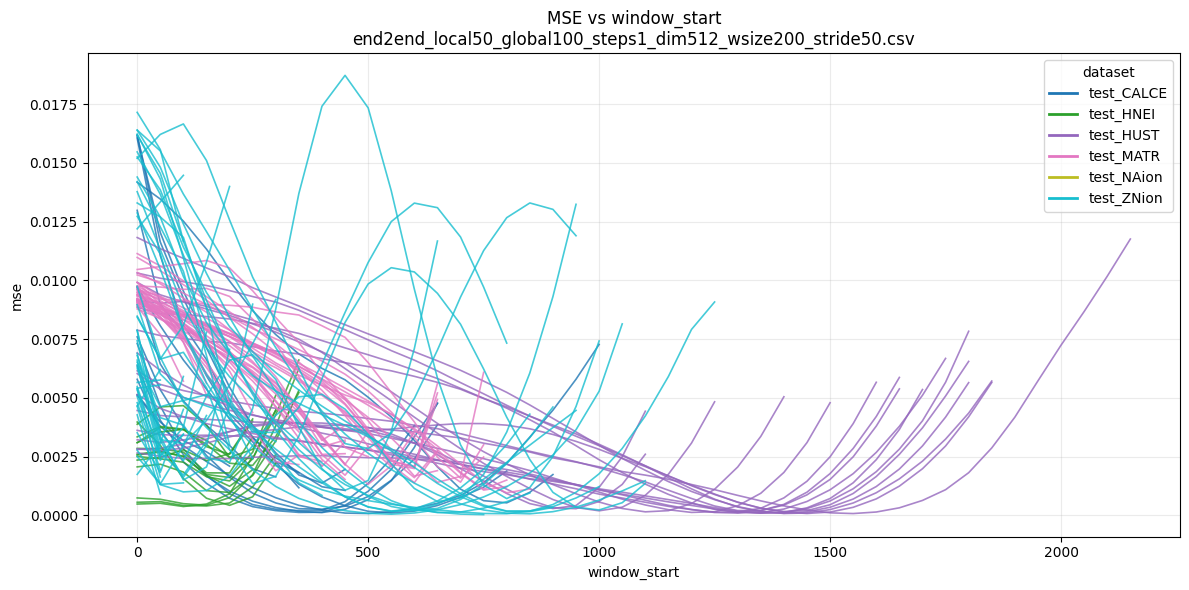

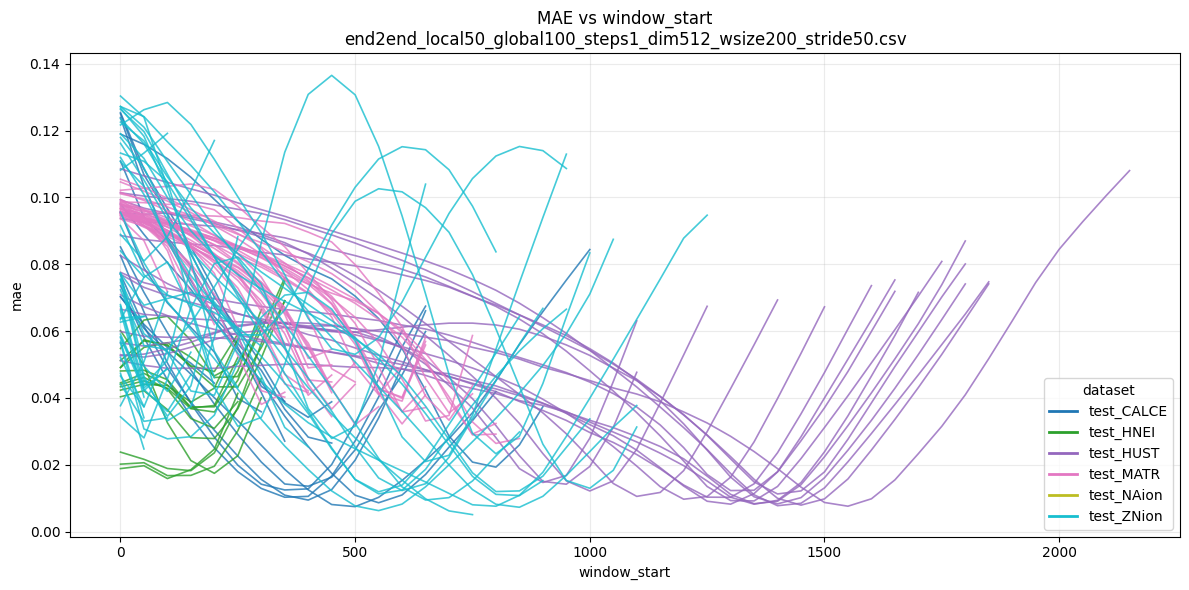

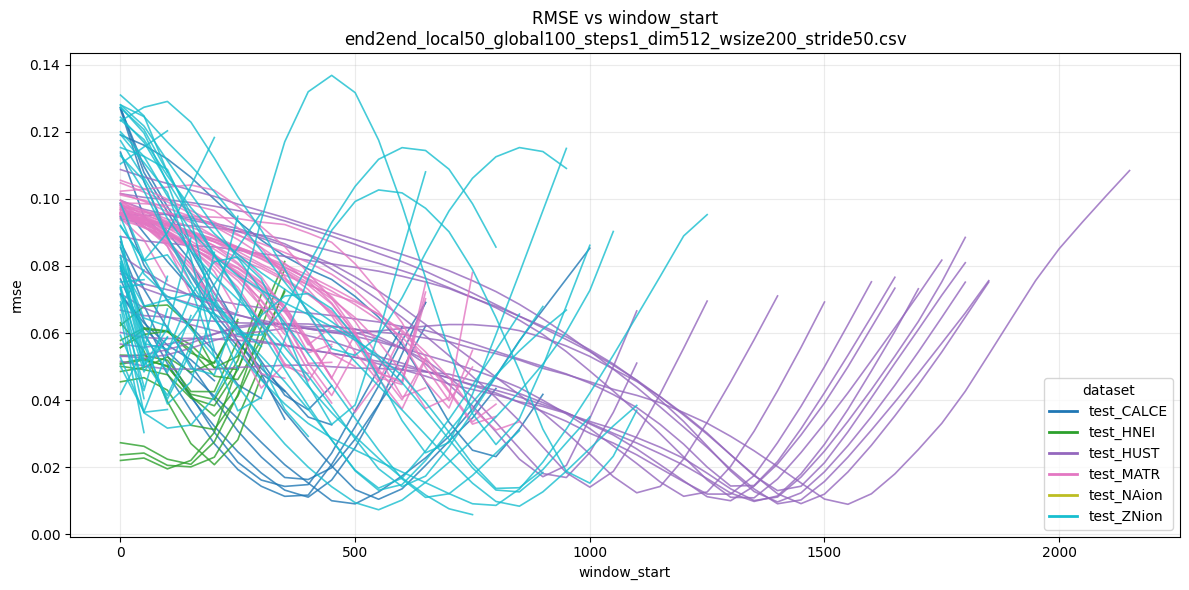

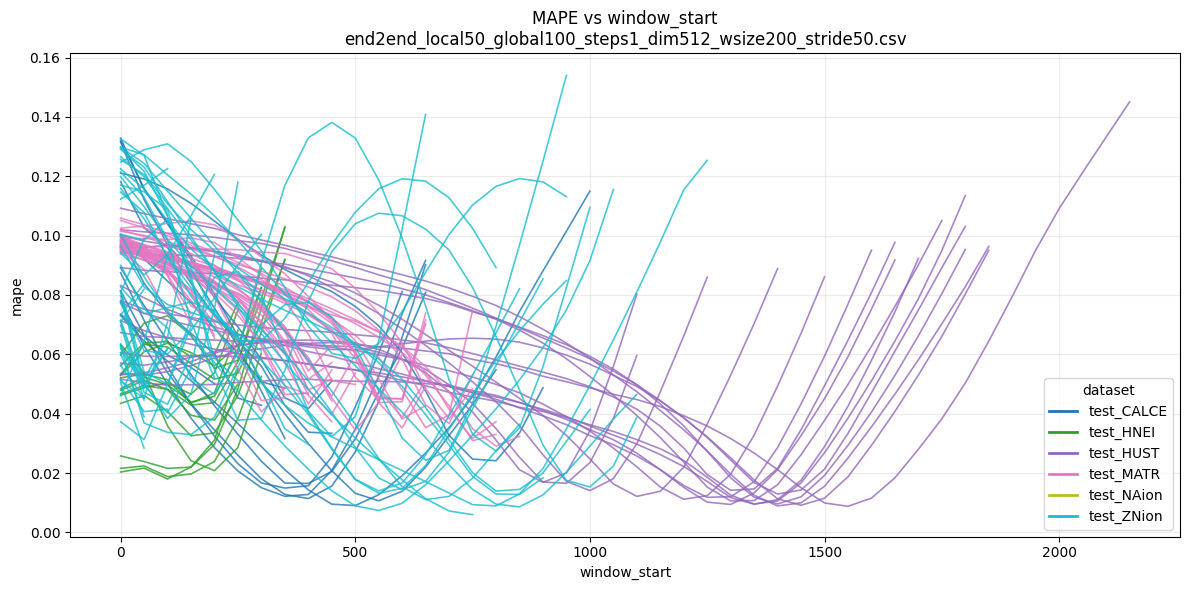

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


def plot_metrics_from_csv(csv_path, figsize=(12, 6), alpha=0.8, linewidth=1.2):
    """给定单个 CSV 路径，绘制 4 张折线图（mse/mae/rmse/mape）。

    规则：
    - x 轴: window_start
    - y 轴: 指标值（mse/mae/rmse/mape）
    - 每个 battery_name 一条线
    - 同一 dataset 使用同一种颜色
    - raw 指标不参与绘图
    """
    RESULT_DIR = Path('/home/syx/workspace/HyperBat/results/diffusion_results')
    csv_path = RESULT_DIR / csv_path
    if not csv_path.exists():
        raise FileNotFoundError(f'CSV 文件不存在: {csv_path}')

    df = pd.read_csv(csv_path)

    required_cols = {'dataset', 'battery_name', 'window_start', 'mse', 'mae', 'rmse', 'mape'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'CSV 缺少必要列: {sorted(missing_cols)}')

    metrics = ['mse', 'mae', 'rmse', 'mape']
    datasets = sorted(df['dataset'].dropna().unique())

    # 为每个 dataset 分配固定颜色
    cmap = plt.get_cmap('tab10', max(len(datasets), 1))
    color_map = {ds: cmap(i) for i, ds in enumerate(datasets)}

    # 按 dataset + battery_name 分组，保证每条线对应一个 battery
    grouped = []
    for (dataset, battery_name), g in df.groupby(['dataset', 'battery_name'], dropna=False):
        g_sorted = g.sort_values('window_start')
        grouped.append((dataset, battery_name, g_sorted))

    for metric in metrics:
        fig, ax = plt.subplots(figsize=figsize)

        for dataset, battery_name, g in grouped:
            ax.plot(
                g['window_start'],
                g[metric],
                color=color_map.get(dataset, 'gray'),
                alpha=alpha,
                linewidth=linewidth,
            )

        ax.set_title(f'{metric.upper()} vs window_start\n{csv_path.name}', fontsize=12)
        ax.set_xlabel('window_start')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

        # 图例只展示 dataset 颜色映射，避免 battery 太多导致图例过长
        legend_handles = [
            Line2D([0], [0], color=color_map[ds], lw=2, label=str(ds))
            for ds in datasets
        ]
        if legend_handles:
            ax.legend(handles=legend_handles, title='dataset', loc='best')

        plt.tight_layout()
        plt.show()

    return df


# 示例：替换为你想看的任意一个 csv 文件
_ = plot_metrics_from_csv('end2end_local50_global100_steps1_dim512_wsize200_stride50.csv')

In [3]:
import os
import math
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.manifold import TSNE
from tqdm import tqdm

from model import WeightDenoiser

# 基础设置
os.environ['OMP_NUM_THREADS'] = '1'
%matplotlib inline

# 导入 BatteryData 路径处理
code_root = str(Path("../").resolve()) 
if code_root not in sys.path:
    sys.path.append(code_root)

try:
    from battery_data import BatteryData
    print("BatteryData 模块导入成功！")
except ImportError:
    print("找不到 battery_data.py")

# ===== 配置 =====
weights_root = Path('../data/weights/wsize_200_stride_50')
labeled_root = Path('../data/labeled')
diffusion_model_path = Path('../models/diffusion/WeightDiffusion_local40_global200_steps1_dim256_wsize200_stride50.pkl')
stats_path = Path('../models/diffusion/diffusion_stats_local40_global200_steps1_dim256_wsize200_stride50.pth')
init_abs_path = Path('../models/gma/GMA_pretrained_abs.pth')

local_num_cycles = 40
global_num_cycles = 200
diffusion_steps = 1
hidden_dim = 256

# t-SNE 大样本会很慢，可按需抽样；None 表示全量
max_samples = None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


class DiffusionSampler:
    def __init__(self, T=1, device='cuda'):
        self.T = T
        self.device = device
        self.betas = torch.linspace(1e-4, 0.02, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)

    @torch.no_grad()
    def sample(self, model, feat_g, feat_l, init_vec=None):
        model.eval()
        if init_vec is not None:
            cur_x = init_vec.to(self.device).view(1, -1)
        else:
            cur_x = torch.randn((1, 385), device=self.device)

        for i in reversed(range(self.T)):
            t = torch.full((1,), i, device=self.device, dtype=torch.long)
            predicted_noise = model(cur_x, t, feat_g, feat_l)
            alpha_t = self.alphas[i]
            alpha_cumprod_t = self.alphas_cumprod[i]
            beta_t = self.betas[i]
            noise = torch.randn_like(cur_x) if i > 0 else 0
            cur_x = (1 / torch.sqrt(alpha_t)) * (
                cur_x - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            ) + torch.sqrt(beta_t) * noise
            cur_x = torch.clamp(cur_x, -5.0, 5.0)

        return cur_x


def load_pretrained_abs_init(path, device):
    if not path.exists():
        return None
    data = torch.load(path, map_location=device)
    if 'init_vec' in data:
        init_vec = data['init_vec'].float().view(-1)
    elif 'param_A' in data and 'param_B' in data and 'param_log_s' in data:
        init_vec = torch.cat([
            data['param_A'].float().view(-1),
            data['param_B'].float().view(-1),
            data['param_log_s'].float().view(-1),
        ])
    else:
        return None
    return init_vec.to(device) if init_vec.numel() == 385 else None


def infer_cycle_input_dim(weights_root, labeled_root):
    subdirs = sorted([d for d in weights_root.iterdir() if d.is_dir()])
    for subdir in subdirs:
        files = sorted(subdir.glob('*.pkl'))
        if not files:
            continue
        f = files[0]
        parts = f.stem.rsplit('_', 1)
        if len(parts) != 2:
            continue
        battery_name = parts[0]
        battery_path = labeled_root / subdir.name / f'{battery_name}.pkl'
        if not battery_path.exists():
            continue
        battery = BatteryData.load(str(battery_path))
        if len(battery.cycle_data) == 0:
            continue
        return int(np.asarray(battery.cycle_data[0].labeled_Qc, dtype=np.float32).shape[-1])
    raise RuntimeError('Cannot infer cond_input_dim from data.')


@torch.no_grad()
def generate_lora_W_vectors(weights_root, labeled_root, denoiser, sampler, stats, init_vec=None):
    t_mean = stats['mean'].to(device)
    t_std = stats['std'].to(device)

    init_vec_norm = None
    if init_vec is not None:
        init_vec_norm = ((init_vec.view(-1).to(device) - t_mean) / (t_std + 1e-8)).view(1, -1)

    rows = []
    subdirs = sorted([d for d in weights_root.iterdir() if d.is_dir()])
    for subdir in subdirs:
        weight_files = sorted(subdir.glob('*.pkl'))
        split_label = 'train' if subdir.name == 'train' else 'test'
        dataset_label = subdir.name

        for f in tqdm(weight_files, desc=f'Generating {subdir.name}'):
            try:
                parts = f.stem.rsplit('_', 1)
                if len(parts) != 2:
                    continue
                battery_name, start_idx_str = parts
                start_idx = int(start_idx_str)

                battery_path = labeled_root / subdir.name / f'{battery_name}.pkl'
                if not battery_path.exists():
                    continue
                battery = BatteryData.load(str(battery_path))

                g_slice = battery.cycle_data[0:global_num_cycles]
                l_slice = battery.cycle_data[start_idx:start_idx + local_num_cycles]
                if len(g_slice) < global_num_cycles or len(l_slice) < local_num_cycles:
                    continue

                g_cyc = np.stack([np.asarray(c.labeled_Qc, dtype=np.float32) for c in g_slice])
                l_cyc = np.stack([np.asarray(c.labeled_Qc, dtype=np.float32) for c in l_slice])

                feat_g = torch.tensor(g_cyc, dtype=torch.float32, device=device).unsqueeze(0)
                feat_l = torch.tensor(l_cyc, dtype=torch.float32, device=device).unsqueeze(0)

                gen_vec_norm = sampler.sample(denoiser, feat_g, feat_l, init_vec=init_vec_norm)
                gen_vec = gen_vec_norm * t_std + t_mean

                p_A = gen_vec[:, 0:256].view(1, 64, 4)
                p_B = gen_vec[:, 256:384].view(1, 4, 32)
                p_log_s = torch.clamp(gen_vec[:, 384:385], min=-5.0, max=5.0)
                W = (torch.exp(p_log_s).view(1, 1, 1) * torch.bmm(p_A, p_B)).squeeze(0).flatten().cpu().numpy()

                rows.append({
                    'split': split_label,
                    'dataset': dataset_label,
                    'battery_name': battery_name,
                    'window_start': start_idx,
                    'weight_vec': W,
                })
            except Exception:
                continue

    return pd.DataFrame(rows)


# ===== 加载模型与统计 =====
if not diffusion_model_path.exists():
    raise FileNotFoundError(f'Model not found: {diffusion_model_path}')
if not stats_path.exists():
    raise FileNotFoundError(f'Stats not found: {stats_path}')

cond_input_dim = infer_cycle_input_dim(weights_root, labeled_root)
print(f'Inferred cond_input_dim = {cond_input_dim}')

denoiser = WeightDenoiser(
    weight_dim=385,
    hidden_dim=hidden_dim,
    cond_input_dim=cond_input_dim,
).to(device)
denoiser.load_state_dict(torch.load(diffusion_model_path, map_location=device))
denoiser.eval()

stats = torch.load(stats_path, map_location=device)
init_vec = load_pretrained_abs_init(init_abs_path, device)
sampler = DiffusionSampler(T=diffusion_steps, device=device)


# ===== 逐样本生成 LoRA 向量 =====
df = generate_lora_W_vectors(weights_root, labeled_root, denoiser, sampler, stats, init_vec=init_vec)
if df.empty:
    raise RuntimeError('No generated LoRA vectors. Please check data/model paths.')

print(f'Total generated samples: {len(df)}')
print(df['split'].value_counts(dropna=False))
print(df['dataset'].value_counts(dropna=False))

if max_samples is not None and len(df) > max_samples:
    df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
    print(f'Downsampled to {len(df)} samples for t-SNE.')


# ===== 画图：颜色按 train/test，形状按 dataset =====
weights_data = np.stack(df['weight_vec'].values)
perp = min(30, len(df) - 1)
tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=perp)
embedding = tsne.fit_transform(weights_data)

plot_df = df.copy()
plot_df['x'] = embedding[:, 0]
plot_df['y'] = embedding[:, 1]

split_color = {'train': '#1f77b4', 'test': '#d62728'}
markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', '*', 'h', '8']
dataset_list = sorted(plot_df['dataset'].dropna().unique())
dataset_marker = {ds: markers[i % len(markers)] for i, ds in enumerate(dataset_list)}

plt.figure(figsize=(13, 9))
ax = plt.gca()

for ds in dataset_list:
    for sp in ['train', 'test']:
        part = plot_df[(plot_df['dataset'] == ds) & (plot_df['split'] == sp)]
        if len(part) == 0:
            continue
        ax.scatter(
            part['x'], part['y'],
            c=split_color.get(sp, '#7f7f7f'),
            marker=dataset_marker[ds],
            s=46, alpha=0.7, edgecolors='gray', linewidths=0.25,
            label=f'{ds} | {sp}',
        )

plt.title('Generated LoRA Manifold (Color: Train/Test, Shape: Dataset)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(
    uniq.values(), uniq.keys(),
    bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9
)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

BatteryData 模块导入成功！
Using device: cuda
Inferred cond_input_dim = 400


Generating train:  12%|█▏        | 761/6480 [04:41<35:13,  2.71it/s] 


KeyboardInterrupt: 

In [7]:
import sys
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm

from model import WeightDenoiser
from battery_data import BatteryData

# 固定使用你指定的模型 pkl
diffusion_model_path = Path('../models/diffusion/WeightDiffusion_local40_global200_steps1_dim256_wsize200_stride50.pkl')
stats_path = Path('../models/diffusion/diffusion_stats_local40_global200_steps1_dim256_wsize200_stride50.pth')
init_abs_path = Path('../models/gma/GMA_pretrained_abs.pth')

# 与该模型对应的配置
weights_root = Path('../data/weights/wsize_200_stride_50')
labeled_root = Path('../data/labeled')
local_num_cycles = 40
global_num_cycles = 200
diffusion_steps = 1
hidden_dim = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


class DiffusionSampler:
    def __init__(self, T=1, device='cuda'):
        self.T = T
        self.device = device
        self.betas = torch.linspace(1e-4, 0.02, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)

    @torch.no_grad()
    def sample(self, model, feat_g, feat_l, init_vec=None):
        model.eval()
        if init_vec is not None:
            cur_x = init_vec.to(self.device).view(1, -1)
        else:
            cur_x = torch.randn((1, 385), device=self.device)

        for i in reversed(range(self.T)):
            t = torch.full((1,), i, device=self.device, dtype=torch.long)
            predicted_noise = model(cur_x, t, feat_g, feat_l)
            alpha_t = self.alphas[i]
            alpha_cumprod_t = self.alphas_cumprod[i]
            beta_t = self.betas[i]
            noise = torch.randn_like(cur_x) if i > 0 else 0
            cur_x = (1 / torch.sqrt(alpha_t)) * (
                cur_x - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            ) + torch.sqrt(beta_t) * noise
            cur_x = torch.clamp(cur_x, -5.0, 5.0)

        return cur_x


def load_pretrained_abs_init(path, device):
    if not path.exists():
        return None
    data = torch.load(path, map_location=device)
    if 'init_vec' in data:
        init_vec = data['init_vec'].float().view(-1)
    elif 'param_A' in data and 'param_B' in data and 'param_log_s' in data:
        init_vec = torch.cat([
            data['param_A'].float().view(-1),
            data['param_B'].float().view(-1),
            data['param_log_s'].float().view(-1),
        ])
    else:
        return None
    return init_vec.to(device) if init_vec.numel() == 385 else None


def infer_cycle_input_dim(weights_root, labeled_root):
    subdirs = sorted([d for d in weights_root.iterdir() if d.is_dir()])
    for subdir in subdirs:
        files = sorted(subdir.glob('*.pkl'))
        if not files:
            continue
        f = files[0]
        parts = f.stem.rsplit('_', 1)
        if len(parts) != 2:
            continue
        battery_name = parts[0]
        battery_path = labeled_root / subdir.name / f'{battery_name}.pkl'
        if not battery_path.exists():
            continue
        battery = BatteryData.load(str(battery_path))
        if len(battery.cycle_data) == 0:
            continue
        return int(np.asarray(battery.cycle_data[0].labeled_Qc, dtype=np.float32).shape[-1])
    raise RuntimeError('Cannot infer cond_input_dim from data.')


def calc_metrics(pred, target):
    pred = pred.detach().cpu().numpy().reshape(-1)
    target = target.detach().cpu().numpy().reshape(-1)
    mse = float(np.mean((pred - target) ** 2))
    mae = float(np.mean(np.abs(pred - target)))
    rmse = float(np.sqrt(mse))
    mape = float(np.mean(np.abs((target - pred) / (np.abs(target) + 1e-8))) * 100.0)
    return mse, mae, rmse, mape


def load_target_and_feats(weight_path, labeled_root, local_num, global_num, eps=1e-8):
    weights = torch.load(weight_path, map_location='cpu')
    p_A = weights['param_A'].float()
    p_B = weights['param_B'].float()

    A_norm = p_A / (torch.norm(p_A, p='fro') + eps)
    B_norm = p_B / (torch.norm(p_B, p='fro') + eps)
    if 'param_log_s' in weights:
        log_s = weights['param_log_s'].float().view(1)
    else:
        norm_val = torch.norm(p_A, p='fro') * torch.norm(p_B, p='fro')
        log_s = torch.log(norm_val + eps).view(1)

    target_vec = torch.cat([A_norm.flatten(), B_norm.flatten(), log_s])

    parts = weight_path.stem.rsplit('_', 1)
    if len(parts) != 2:
        raise ValueError(f'Invalid weight filename: {weight_path.name}')
    battery_name, start_idx_str = parts
    start_idx = int(start_idx_str)

    dataset_name = weight_path.parent.name
    battery_path = labeled_root / dataset_name / f'{battery_name}.pkl'
    if not battery_path.exists():
        raise FileNotFoundError(f'Battery file not found: {battery_path}')

    battery = BatteryData.load(str(battery_path))
    g_slice = battery.cycle_data[0:global_num]
    l_slice = battery.cycle_data[start_idx:start_idx + local_num]
    if len(g_slice) < global_num or len(l_slice) < local_num:
        raise ValueError(f'Insufficient cycles for {weight_path.name}')

    g_cyc = np.stack([np.asarray(c.labeled_Qc, dtype=np.float32) for c in g_slice])
    l_cyc = np.stack([np.asarray(c.labeled_Qc, dtype=np.float32) for c in l_slice])

    feat_g = torch.tensor(g_cyc, dtype=torch.float32, device=device).unsqueeze(0)
    feat_l = torch.tensor(l_cyc, dtype=torch.float32, device=device).unsqueeze(0)
    return target_vec.to(device), feat_g, feat_l, dataset_name


if not diffusion_model_path.exists():
    raise FileNotFoundError(f'Model not found: {diffusion_model_path}')
if not stats_path.exists():
    raise FileNotFoundError(f'Stats not found: {stats_path}')

cond_input_dim = infer_cycle_input_dim(weights_root, labeled_root)
denoiser = WeightDenoiser(weight_dim=385, hidden_dim=hidden_dim, cond_input_dim=cond_input_dim).to(device)
denoiser.load_state_dict(torch.load(diffusion_model_path, map_location=device))
denoiser.eval()

stats = torch.load(stats_path, map_location=device)
t_mean = stats['mean'].to(device)
t_std = stats['std'].to(device)
init_vec = load_pretrained_abs_init(init_abs_path, device)
sampler = DiffusionSampler(T=diffusion_steps, device=device)

init_vec_norm = None
if init_vec is not None:
    init_vec_norm = ((init_vec.view(-1).to(device) - t_mean) / (t_std + 1e-8)).view(1, -1)

dataset_metrics = {}
subdirs = sorted([d for d in weights_root.iterdir() if d.is_dir()])

for subdir in subdirs:
    weight_files = sorted(subdir.glob('*.pkl'))
    if not weight_files:
        continue

    dataset_name = subdir.name
    dataset_metrics[dataset_name] = {
        'mse_A': [], 'mae_A': [], 'rmse_A': [], 'mape_A': [],
        'mse_B': [], 'mae_B': [], 'rmse_B': [], 'mape_B': [],
        'mse_S': [], 'mae_S': [], 'rmse_S': [], 'mape_S': [],
        'mse_W': [], 'mae_W': [], 'rmse_W': [], 'mape_W': [],
    }

    for wf in tqdm(weight_files, desc=f'Eval {dataset_name}'):
        try:
            target_vec_raw, feat_g, feat_l, _ = load_target_and_feats(
                wf, labeled_root, local_num_cycles, global_num_cycles
            )

            with torch.no_grad():
                gen_vec_norm = sampler.sample(denoiser, feat_g, feat_l, init_vec=init_vec_norm)
            gen_vec = (gen_vec_norm * t_std + t_mean).squeeze(0)

            pred_A = gen_vec[0:256]
            pred_B = gen_vec[256:384]
            pred_S = gen_vec[384:385]

            target_A = target_vec_raw[0:256]
            target_B = target_vec_raw[256:384]
            target_S = target_vec_raw[384:385]

            mse_A, mae_A, rmse_A, mape_A = calc_metrics(pred_A, target_A)
            mse_B, mae_B, rmse_B, mape_B = calc_metrics(pred_B, target_B)
            mse_S, mae_S, rmse_S, mape_S = calc_metrics(pred_S, target_S)

            pred_W = torch.exp(pred_S).view(1, 1, 1) * torch.bmm(pred_A.view(1, 64, 4), pred_B.view(1, 4, 32))
            target_W = torch.exp(target_S).view(1, 1, 1) * torch.bmm(target_A.view(1, 64, 4), target_B.view(1, 4, 32))
            mse_W, mae_W, rmse_W, mape_W = calc_metrics(pred_W.flatten(), target_W.flatten())

            dataset_metrics[dataset_name]['mse_A'].append(mse_A)
            dataset_metrics[dataset_name]['mae_A'].append(mae_A)
            dataset_metrics[dataset_name]['rmse_A'].append(rmse_A)
            dataset_metrics[dataset_name]['mape_A'].append(mape_A)

            dataset_metrics[dataset_name]['mse_B'].append(mse_B)
            dataset_metrics[dataset_name]['mae_B'].append(mae_B)
            dataset_metrics[dataset_name]['rmse_B'].append(rmse_B)
            dataset_metrics[dataset_name]['mape_B'].append(mape_B)

            dataset_metrics[dataset_name]['mse_S'].append(mse_S)
            dataset_metrics[dataset_name]['mae_S'].append(mae_S)
            dataset_metrics[dataset_name]['rmse_S'].append(rmse_S)
            dataset_metrics[dataset_name]['mape_S'].append(mape_S)

            dataset_metrics[dataset_name]['mse_W'].append(mse_W)
            dataset_metrics[dataset_name]['mae_W'].append(mae_W)
            dataset_metrics[dataset_name]['rmse_W'].append(rmse_W)
            dataset_metrics[dataset_name]['mape_W'].append(mape_W)
        except Exception:
            continue

rows = []
for ds in sorted(dataset_metrics.keys()):
    m = dataset_metrics[ds]
    if len(m['mse_A']) == 0:
        continue
    rows.append({
        'dataset': ds,
        'mse_A': float(np.mean(m['mse_A'])),
        'mae_A': float(np.mean(m['mae_A'])),
        'rmse_A': float(np.mean(m['rmse_A'])),
        'mape_A': float(np.mean(m['mape_A'])),
        'mse_B': float(np.mean(m['mse_B'])),
        'mae_B': float(np.mean(m['mae_B'])),
        'rmse_B': float(np.mean(m['rmse_B'])),
        'mape_B': float(np.mean(m['mape_B'])),
        'mse_S': float(np.mean(m['mse_S'])),
        'mae_S': float(np.mean(m['mae_S'])),
        'rmse_S': float(np.mean(m['rmse_S'])),
        'mape_S': float(np.mean(m['mape_S'])),
        'mse_W': float(np.mean(m['mse_W'])),
        'mae_W': float(np.mean(m['mae_W'])),
        'rmse_W': float(np.mean(m['rmse_W'])),
        'mape_W': float(np.mean(m['mape_W'])),
    })

if not rows:
    raise RuntimeError('No valid samples were evaluated. Please check paths and data consistency.')

result_df = pd.DataFrame(rows, columns=[
    'dataset',
    'mse_A', 'mae_A', 'rmse_A', 'mape_A',
    'mse_B', 'mae_B', 'rmse_B', 'mape_B',
    'mse_S', 'mae_S', 'rmse_S', 'mape_S',
    'mse_W', 'mae_W', 'rmse_W', 'mape_W',
])

display(result_df)

Using device: cuda


Eval train: 100%|██████████| 6480/6480 [38:45<00:00,  2.79it/s]  


,dataset,mse_A,mae_A,rmse_A,mape_A,mse_B,mae_B,rmse_B,mape_B,mse_S,mae_S,rmse_S,mape_S,mse_W,mae_W,rmse_W,mape_W
0,test_CALCE,0.007636,0.061165,0.087322,394.785444,0.015251,0.088736,0.123265,298.562117,0.085675,0.243127,0.243127,24.959203,0.001853,0.025938,0.042520,209.119100
1,test_HNEI,0.007491,0.061805,0.086497,284.382226,0.015726,0.091898,0.125237,718.594653,0.199236,0.446340,0.446340,32.304523,0.002659,0.036361,0.051561,147.382378
2,test_HUST,0.007446,0.060475,0.086180,284.846137,0.015449,0.083908,0.123972,364.430555,0.005515,0.058679,0.058679,6.514958,0.001287,0.015195,0.035799,168.636840
3,test_MATR,0.007644,0.060865,0.087383,237.818420,0.015530,0.085586,0.124271,237.537788,0.075884,0.214504,0.214504,17.338384,0.001989,0.024533,0.044079,154.156285
4,test_NAion,0.007693,0.060372,0.087638,200.899370,0.015494,0.090697,0.124031,183.780593,0.199298,0.446428,0.446428,32.309410,0.002881,0.033499,0.053662,118.177276
5,test_ZNion,0.007773,0.064179,0.088130,337.573774,0.015445,0.091353,0.124111,384.622017,0.196497,0.263572,0.263572,24.917135,0.001685,0.022669,0.040073,1235.046802
6,train,0.007666,0.061581,0.087490,324.203942,0.015517,0.087059,0.124287,416.090266,0.162989,0.196809,0.196809,15.286232,0.001727,0.022539,0.040993,46535.448556
